WEEK_2_Day_11_SreetamaSantra — Reproducible Preprocessing Pipeline
# LG HG2 18650 Li-ion Battery Dataset (McMaster University)
# Sreetama Santra | TIH IIT Guwahati | 2026-08-30
# Implements all 10 cleaning rules (R1–R10) from Day 8/9 approved plan.
# Produces: cleaned DataFrames, leakage-safe splits, fitted scaler,
# SoC labels, engineered features — all saved as joblib files.

In [1]:
# Section 0: Imports, Seeds and Configuration
import zipfile, io, os, warnings
import pandas as pd
import numpy as np
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Fixed seed — must match across all notebooks
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

ZIP_PATH  = "SOC DATA SET.zip"
SAVE_DIR  = "preprocessed"       # output directory
os.makedirs(SAVE_DIR, exist_ok=True)

# Temperature folders and display labels
TEMPS  = ['40degC', '25degC', '10degC', '0degC', 'n10degC', 'n20degC']
LABELS = {
    '40degC':'40°C', '25degC':'25°C', '10degC':'10°C',
    '0degC':'0°C', 'n10degC':'−10°C', 'n20degC':'−20°C'
}

# Temperature-specific nominal capacity (Ah) from Cap_1C files
# Used to normalise SoC per temperature — prevents incorrect SoC scaling
Q_NOMINAL = {
    '40degC': 2.53, '25degC': 2.59, '10degC': 2.48,
    '0degC':  2.35, 'n10degC': 2.13, 'n20degC': 1.59
}

# Split assignment — file-level, never row-level (R8)
TRAIN_MIXED   = ['Mixed1','Mixed2','Mixed3','Mixed4','Mixed5','Mixed6']
VAL_MIXED     = ['Mixed7']
TEST_MIXED    = ['Mixed8']
DRIVE_CYCLES  = ['UDDS','HWFET','LA92','US06']

TRAIN_CHARGE_MAX = 12   # Charge1–Charge12 -> training
VAL_CHARGE_MAX   = 14   # Charge13–Charge14 -> validation
# Charge15–Charge16 -> test

ROLLING_WINDOW = 10     # rows for rolling mean features
MIN_CHARGE_ROWS = 500   # R7 — exclude short Charge files (provisional)

# Input features (Capacity excluded, it is the SoC label source, R4 leakage)
FEATURE_COLS = [
    'Voltage', 'Current', 'Temperature', 'Power',
    'rolling_mean_voltage', 'rolling_mean_current',
    'dV_dt', 'time_elapsed', 'cc_cv_flag'
]

print("Configuration loaded.")
print(f"Random seed: {RANDOM_SEED}")
print(f"Output directory: {SAVE_DIR}/")
print(f"Q_nominal values (Ah): {Q_NOMINAL}")

Configuration loaded.
Random seed: 42
Output directory: preprocessed/
Q_nominal values (Ah): {'40degC': 2.53, '25degC': 2.59, '10degC': 2.48, '0degC': 2.35, 'n10degC': 2.13, 'n20degC': 1.59}


In [2]:
# Section 1: Core Loading Function (R1, R2, R3)
def load_and_clean(z, path, temp_key):
    """
    Load one CSV and apply all active cleaning rules:
    R1 - Drop unit descriptor row (index 0 after header)
    R2 - Filter Status = PAU rows
    R3 - Force numeric dtype on all sensor columns
    R6 - Use measured Temperature column (not folder name)
    """
    with z.open(path) as f:
        raw = f.read().decode('latin-1').split('\n')

    # Find header row (contains 'Voltage' and 'Current')
    header_row = 0
    for i, line in enumerate(raw):
        if 'Voltage' in line and 'Current' in line:
            header_row = i
            break

    df = pd.read_csv(
        io.StringIO('\n'.join(raw[header_row:])),
        low_memory=False
    )
    df.columns = [c.strip() for c in df.columns]

    # R1 - Drop unit descriptor row (V, A, °C, Ah strings)
    df = df.drop(index=0).reset_index(drop=True)

    # R3 - Force numeric dtype
    sensor_cols = ['Voltage', 'Current', 'Temperature', 'Capacity', 'WhAccu', 'Cnt', 'Step', 'Cycle']
    for col in sensor_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # R2 - Filter PAU rows
    if 'Status' in df.columns:
        df = df[df['Status'] == 'TABLE'].reset_index(drop=True)

    # Add metadata
    df['_temp_key']   = temp_key
    df['_temp_label'] = LABELS[temp_key]
    df['_source_file'] = path.split('/')[-1]

    return df

In [3]:
# Section 2 - SoC Label Derivation

def derive_soc(df, temp_key):
    """
    Derive SoC from Capacity column using Coulomb counting (per file).
    Uses temperature-specific Q_nominal to correct for capacity reduction at cold temps.

    Capacity is always <= 0 in discharge files (cumulative Ah removed from cell).
    SoC formula:  SoC(t) = 100 + (Capacity_t / Q_nominal) * 100
    At segment start: Capacity = 0 → SoC = 100%
    At full discharge: Capacity = -Q_nominal → SoC = 0%
    """
    q_nom = Q_NOMINAL[temp_key]
    df = df.copy()
    df['SoC'] = (100.0 + (df['Capacity'] / q_nom) * 100.0).clip(0.0, 100.0)
    return df

In [4]:
# Section 3- Feature Engineering (R10 - within each file)

def engineer_features(df):
    """
    All rolling features computed within this single file's DataFrame.
    R10 — never roll across file boundaries.
    """
    df = df.copy()

    # Power = Voltage × |Current|
    df['Power'] = df['Voltage'] * df['Current'].abs()

    # Rolling mean of voltage (window=10 rows)
    df['rolling_mean_voltage'] = (
        df['Voltage'].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    )

    # Rolling mean of current (window=10 rows)
    df['rolling_mean_current'] = (
        df['Current'].rolling(window=ROLLING_WINDOW, min_periods=1).mean()
    )

    # Rate of change of voltage (dV/dt)
    df['dV_dt'] = df['Voltage'].diff().fillna(0.0)

    # Time elapsed (row index × 0.1s sample rate for drive cycles)
    df['time_elapsed'] = df.index * 0.1

    # CC/CV phase flag - 1 if current is low and positive (CV phase during charge)
    # For drive cycle files: 1 if |current| < 0.5A (rest), else 0
    df['cc_cv_flag'] = (df['Current'].abs() < 0.5).astype(int)

    return df

In [5]:
# Section 4: Classify Files into Split Buckets
def classify_file(filename):
    """
    Assign a file to train / val / test based on filename pattern.
    Returns: 'train', 'val', 'test', or None (skip file)
    """
    name = filename.replace('.csv', '')

    # Mixed drive cycle files
    for tag in TRAIN_MIXED:
        if tag in name:
            return 'train'
    if 'Mixed7' in name:
        return 'val'
    if 'Mixed8' in name:
        return 'test'

    # Standard drive cycles — all go to test
    for dc in DRIVE_CYCLES:
        if dc in name:
            return 'test'

    # Charge files — numbered assignment
    if 'Charge' in name:
        import re
        nums = re.findall(r'\d+', name.split('Charge')[-1])
        if nums:
            n = int(nums[0])
            if n <= TRAIN_CHARGE_MAX:
                return 'train'
            elif n <= VAL_CHARGE_MAX:
                return 'val'
            else:
                return 'test'
        else:
            # Unnumbered charge file (e.g. 549_Charge.csv) — skip
            return None

    return None   # HPPC, Cap, Dis files — not used in modelling

In [6]:
# Section 5: Build the Full Dataset
print("\n" + "="*60)
print("SECTION 5: LOADING AND PREPROCESSING ALL FILES")
print("="*60)

train_dfs, val_dfs, test_dfs = [], [], []
skipped = []
file_log = []

with zipfile.ZipFile(ZIP_PATH) as z:
    all_files = sorted([f for f in z.namelist() if f.endswith('.csv')])

    for filepath in all_files:
        parts = filepath.split('/')
        if len(parts) < 3:
            continue

        temp_key = parts[1]
        if temp_key not in TEMPS:
            continue

        filename = parts[2]
        split    = classify_file(filename)

        if split is None:
            skipped.append(filepath)
            continue

        # Load and clean
        df = load_and_clean(z, filepath, temp_key)

        if len(df) == 0:
            skipped.append(filepath + " [empty after cleaning]")
            continue

        # R7 — Skip short Charge files
        if 'Charge' in filename and len(df) < MIN_CHARGE_ROWS:
            skipped.append(filepath + f" [only {len(df)} rows < {MIN_CHARGE_ROWS}]")
            continue

        # Derive SoC labels
        df = derive_soc(df, temp_key)

        # Feature engineering — per file (R10)
        df = engineer_features(df)

        # Add split label
        df['_split'] = split

        # Log
        file_log.append({
            'file': filename, 'temp': temp_key,
            'split': split, 'rows': len(df),
            'soc_min': round(df['SoC'].min(), 2),
            'soc_max': round(df['SoC'].max(), 2)
        })

        if split == 'train':
            train_dfs.append(df)
        elif split == 'val':
            val_dfs.append(df)
        else:
            test_dfs.append(df)

# Concatenate splits
train_df = pd.concat(train_dfs, ignore_index=True)
val_df   = pd.concat(val_dfs,   ignore_index=True)
test_df  = pd.concat(test_dfs,  ignore_index=True)

print(f"\nTraining set:   {len(train_df):>8,} rows  | {len(train_dfs)} files")
print(f"Validation set: {len(val_df):>8,} rows  | {len(val_dfs)} files")
print(f"Test set:       {len(test_df):>8,} rows  | {len(test_dfs)} files")
print(f"Total:          {len(train_df)+len(val_df)+len(test_df):>8,} rows")
print(f"Skipped:        {len(skipped)} files")

print("\nSplit file log (first 15):")
log_df = pd.DataFrame(file_log)
print(log_df.head(15).to_string(index=False))


SECTION 5: LOADING AND PREPROCESSING ALL FILES

Training set:   1,849,732 rows  | 34 files
Validation set:  272,565 rows  | 6 files
Test set:       1,956,241 rows  | 30 files
Total:          4,078,538 rows
Skipped:        138 files

Split file log (first 15):
          file   temp split   rows  soc_min  soc_max
 589_HWFET.csv  0degC  test  43677     0.01    100.0
  589_LA92.csv  0degC  test  75576     0.01    100.0
589_Mixed1.csv  0degC train  61311     0.01    100.0
589_Mixed2.csv  0degC train  66302     0.01    100.0
  589_UDDS.csv  0degC  test 134434     0.01    100.0
  589_US06.csv  0degC  test  27805     0.01    100.0
590_Mixed4.csv  0degC train  62026     0.95    100.0
590_Mixed5.csv  0degC train  58994     0.95    100.0
590_Mixed6.csv  0degC train  56482     0.95    100.0
590_Mixed7.csv  0degC   val  55539     0.95    100.0
590_Mixed8.csv  0degC  test  69837     0.95    100.0
567_Mixed1.csv 10degC train  66328     0.01    100.0
567_Mixed2.csv 10degC train  71751     0.02    100

In [7]:
# Section 6: Data Integrity Checks
print("\n" + "="*60)
print("SECTION 6: DATA INTEGRITY CHECKS")
print("="*60)

for name, df in [("Train", train_df), ("Val", val_df), ("Test", test_df)]:
    nan_count = df[FEATURE_COLS + ['SoC']].isnull().sum().sum()
    soc_range = f"{df['SoC'].min():.1f}% to {df['SoC'].max():.1f}%"
    temps_present = sorted(df['_temp_label'].unique())
    print(f"\n{name}:")
    print(f"  Rows: {len(df):,}  |  NaN in features+SoC: {nan_count}  |  SoC range: {soc_range}")
    print(f"  Temperatures: {temps_present}")
    print(f"  PAU rows remaining: {(df.get('Status','') == 'PAU').sum()}")

# Verify no data leakage — check that no file appears in two splits
train_files = set(train_df['_source_file'].unique())
val_files   = set(val_df['_source_file'].unique())
test_files  = set(test_df['_source_file'].unique())

tv_overlap  = train_files & val_files
tt_overlap  = train_files & test_files
vt_overlap  = val_files   & test_files

print(f"\nLeakage check:")
print(f"  Train ∩ Val:  {len(tv_overlap)} files  {'✓ Clean' if not tv_overlap else '✗ LEAK: ' + str(tv_overlap)}")
print(f"  Train ∩ Test: {len(tt_overlap)} files  {'✓ Clean' if not tt_overlap else '✗ LEAK: ' + str(tt_overlap)}")
print(f"  Val ∩ Test:   {len(vt_overlap)} files  {'✓ Clean' if not vt_overlap else '✗ LEAK: ' + str(vt_overlap)}")


SECTION 6: DATA INTEGRITY CHECKS

Train:
  Rows: 1,849,732  |  NaN in features+SoC: 0  |  SoC range: 0.0% to 100.0%
  Temperatures: ['0°C', '10°C', '25°C', '40°C', '−10°C', '−20°C']
  PAU rows remaining: 0

Val:
  Rows: 272,565  |  NaN in features+SoC: 0  |  SoC range: 0.9% to 100.0%
  Temperatures: ['0°C', '10°C', '25°C', '40°C', '−10°C', '−20°C']
  PAU rows remaining: 0

Test:
  Rows: 1,956,241  |  NaN in features+SoC: 15  |  SoC range: 0.0% to 100.0%
  Temperatures: ['0°C', '10°C', '25°C', '40°C', '−10°C', '−20°C']
  PAU rows remaining: 0

Leakage check:
  Train ∩ Val:  0 files  ✓ Clean
  Train ∩ Test: 0 files  ✓ Clean
  Val ∩ Test:   0 files  ✓ Clean


In [9]:
# Section 7: Feature Scaling (R9 — fit on training only)
print("\n" + "="*60)
print("SECTION 7: FEATURE SCALING")
print("="*60)

# Drop rows with NaN in feature columns before scaling
train_clean = train_df.dropna(subset=FEATURE_COLS + ['SoC'])
val_clean   = val_df.dropna(subset=FEATURE_COLS + ['SoC'])
test_clean  = test_df.dropna(subset=FEATURE_COLS + ['SoC'])

print(f"Rows after NaN drop — Train: {len(train_clean):,}  Val: {len(val_clean):,}  Test: {len(test_clean):,}")

# Extract feature matrices
X_train = train_clean[FEATURE_COLS].values
X_val   = val_clean[FEATURE_COLS].values
X_test  = test_clean[FEATURE_COLS].values

# Target arrays
y_train_soc = train_clean['SoC'].values
y_val_soc   = val_clean['SoC'].values
y_test_soc  = test_clean['SoC'].values

# R9 — Fit scaler on training data ONLY
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit + transform
X_val_scaled   = scaler.transform(X_val)          # transform only
X_test_scaled  = scaler.transform(X_test)         # transform only

print("\nScaler statistics (fitted on training data):")
for i, feat in enumerate(FEATURE_COLS):
    print(f"  {feat:<25}  mean={scaler.mean_[i]:>8.4f}  std={scaler.scale_[i]:>8.4f}")

print(f"\nScaled array shapes:")
print(f"  X_train: {X_train_scaled.shape}  y_train_soc: {y_train_soc.shape}")
print(f"  X_val:   {X_val_scaled.shape}  y_val_soc:   {y_val_soc.shape}")
print(f"  X_test:  {X_test_scaled.shape}  y_test_soc:  {y_test_soc.shape}")


SECTION 7: FEATURE SCALING
Rows after NaN drop — Train: 1,849,732  Val: 272,565  Test: 1,956,238

Scaler statistics (fitted on training data):
  Voltage                    mean=  3.6879  std=  0.2823
  Current                    mean= -1.3413  std=  2.4956
  Temperature                mean=  8.0536  std= 17.7416
  Power                      mean=  7.0699  std=  6.9448
  rolling_mean_voltage       mean=  3.6880  std=  0.2815
  rolling_mean_current       mean= -1.3409  std=  2.4281
  dV_dt                      mean= -0.0000  std=  0.0119
  time_elapsed               mean=3044.5583  std=1889.9285
  cc_cv_flag                 mean=  0.2777  std=  0.4479

Scaled array shapes:
  X_train: (1849732, 9)  y_train_soc: (1849732,)
  X_val:   (272565, 9)  y_val_soc:   (272565,)
  X_test:  (1956238, 9)  y_test_soc:  (1956238,)



SECTION 8: SoC DISTRIBUTION AFTER SPLIT
  Train SoC   0– 20%:  289,443 rows  (15.6%)
  Train SoC  20– 40%:  361,666 rows  (19.6%)
  Train SoC  40– 60%:  434,144 rows  (23.5%)
  Train SoC  60– 80%:  315,945 rows  (17.1%)
  Train SoC  80–100%:  448,534 rows  (24.2%)
  Validation SoC   0– 20%:   49,381 rows  (18.1%)
  Validation SoC  20– 40%:   47,685 rows  (17.5%)
  Validation SoC  40– 60%:   68,883 rows  (25.3%)
  Validation SoC  60– 80%:   65,084 rows  (23.9%)
  Validation SoC  80–100%:   41,532 rows  (15.2%)
  Test SoC   0– 20%:  342,024 rows  (17.5%)
  Test SoC  20– 40%:  383,962 rows  (19.6%)
  Test SoC  40– 60%:  373,639 rows  (19.1%)
  Test SoC  60– 80%:  407,362 rows  (20.8%)
  Test SoC  80–100%:  449,251 rows  (23.0%)


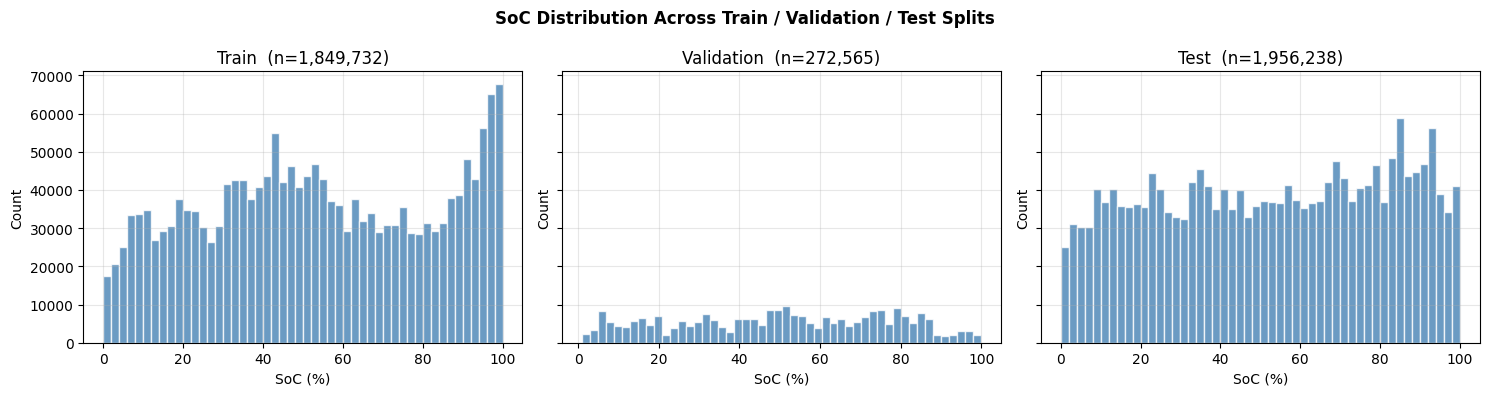


Interpretation:
  - All three splits should have similar SoC distributions for fair comparison.
  - Low SoC (0–20%) remains underrepresented across all splits — expected.
  - Any large imbalance would indicate the file-level split introduced bias.


In [10]:
# Section 8: SoC Distribution Check After Split
print("\n" + "="*60)
print("SECTION 8: SoC DISTRIBUTION AFTER SPLIT")
print("="*60)

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, (name, y) in zip(axes, [("Train", y_train_soc),
                                  ("Validation", y_val_soc),
                                  ("Test", y_test_soc)]):
    ax.hist(y, bins=50, color='steelblue', alpha=0.8, edgecolor='white', lw=0.4)
    ax.set_xlabel('SoC (%)')
    ax.set_ylabel('Count')
    ax.set_title(f'{name}  (n={len(y):,})')
    ax.grid(True, alpha=0.3)

    bins_check = [0, 20, 40, 60, 80, 100]
    counts, _ = np.histogram(y, bins=bins_check)
    for j, (lo, hi, cnt) in enumerate(zip(bins_check, bins_check[1:], counts)):
        pct = cnt / len(y) * 100
        print(f"  {name} SoC {lo:>3}–{hi:>3}%:  {cnt:>7,} rows  ({pct:.1f}%)")

plt.suptitle('SoC Distribution Across Train / Validation / Test Splits',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("  - All three splits should have similar SoC distributions for fair comparison.")
print("  - Low SoC (0–20%) remains underrepresented across all splits — expected.")
print("  - Any large imbalance would indicate the file-level split introduced bias.")

In [11]:
# Section 9: Save Preprocessed Objects
print("\n" + "="*60)
print("SECTION 9: SAVING PREPROCESSED OBJECTS")
print("="*60)

# Save scaled arrays and targets
np.save(f"{SAVE_DIR}/X_train_scaled.npy", X_train_scaled)
np.save(f"{SAVE_DIR}/X_val_scaled.npy",   X_val_scaled)
np.save(f"{SAVE_DIR}/X_test_scaled.npy",  X_test_scaled)
np.save(f"{SAVE_DIR}/y_train_soc.npy",    y_train_soc)
np.save(f"{SAVE_DIR}/y_val_soc.npy",      y_val_soc)
np.save(f"{SAVE_DIR}/y_test_soc.npy",     y_test_soc)

# Save fitted scaler (R9 — must be reused for all future inference)
joblib.dump(scaler, f"{SAVE_DIR}/scaler.joblib")

# Save feature column list (for reference when loading model)
joblib.dump(FEATURE_COLS, f"{SAVE_DIR}/feature_cols.joblib")

# Save file log
log_df.to_csv(f"{SAVE_DIR}/file_split_log.csv", index=False)

# Save metadata
metadata = {
    'random_seed':      RANDOM_SEED,
    'rolling_window':   ROLLING_WINDOW,
    'min_charge_rows':  MIN_CHARGE_ROWS,
    'q_nominal':        Q_NOMINAL,
    'feature_cols':     FEATURE_COLS,
    'train_files':      len(train_dfs),
    'val_files':        len(val_dfs),
    'test_files':       len(test_dfs),
    'train_rows':       len(train_clean),
    'val_rows':         len(val_clean),
    'test_rows':        len(test_clean),
}
joblib.dump(metadata, f"{SAVE_DIR}/preprocessing_metadata.joblib")

print("Saved files:")
for f in sorted(os.listdir(SAVE_DIR)):
    size_kb = os.path.getsize(f"{SAVE_DIR}/{f}") / 1024
    print(f"  {f:<40} {size_kb:>8.1f} KB")


SECTION 9: SAVING PREPROCESSED OBJECTS
Saved files:
  X_test_scaled.npy                        137548.1 KB
  X_train_scaled.npy                       130059.4 KB
  X_val_scaled.npy                          19164.9 KB
  feature_cols.joblib                           0.1 KB
  file_split_log.csv                            3.0 KB
  preprocessing_metadata.joblib                 0.4 KB
  scaler.joblib                                 0.8 KB
  y_test_soc.npy                            15283.2 KB
  y_train_soc.npy                           14451.2 KB
  y_val_soc.npy                              2129.5 KB
